Steps needed:
- load results
- figure out which LSOAs fall into which wards
- for the 4 outliers
    -  split em 50/50 for now
- then start assigning officers
    - 800 hrs a week
    - need to be able to split it into 100 officers that only work a max 4 days/week

# Tobias' work

In [34]:
import geopandas as gpd
import plotly.express as px
import json
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os


In [21]:
# Find LSOAs in multiple wards


lsoas = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\LSOAs.geojson")
wards = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\wards.geojson")

# Calculate area
lsoas["LSOA_area"] = lsoas.geometry.area


joined = gpd.sjoin(lsoas, wards, how='inner', predicate='intersects')

overlap_counts = joined.groupby(joined.index).size()
lsoas_with_multiple_wards = overlap_counts[overlap_counts > 1]
overlap_lsoas_names = lsoas.loc[lsoas_with_multiple_wards.index, "LSOA11NM"].tolist()

print(f"{len(lsoas_with_multiple_wards)} LSOAs in more than one ward")
print("LSOA names with multiple ward intersections:", overlap_lsoas_names)


4225 LSOAs in more than one ward
LSOA names with multiple ward intersections: ['City of London 001B', 'City of London 001C', 'City of London 001E', 'Barking and Dagenham 016A', 'Barking and Dagenham 015B', 'Barking and Dagenham 016B', 'Barking and Dagenham 015C', 'Barking and Dagenham 016C', 'Barking and Dagenham 015D', 'Barking and Dagenham 013A', 'Barking and Dagenham 013B', 'Barking and Dagenham 009A', 'Barking and Dagenham 009B', 'Barking and Dagenham 009C', 'Barking and Dagenham 023A', 'Barking and Dagenham 023B', 'Barking and Dagenham 008A', 'Barking and Dagenham 008C', 'Barking and Dagenham 008D', 'Barking and Dagenham 008E', 'Barking and Dagenham 001A', 'Barking and Dagenham 001B', 'Barking and Dagenham 001C', 'Barking and Dagenham 002A', 'Barking and Dagenham 002B', 'Barking and Dagenham 006A', 'Barking and Dagenham 003A', 'Barking and Dagenham 010A', 'Barking and Dagenham 010B', 'Barking and Dagenham 003B', 'Barking and Dagenham 003C', 'Barking and Dagenham 003D', 'Barking an

In [22]:
# Calculate area of LSOA within each ward it intersects


lsoas_multi = lsoas.loc[lsoas_with_multiple_wards.index]
joined_multi = joined.loc[lsoas_with_multiple_wards.index]

joined_multi = joined_multi.merge(
    wards[["geometry", "Name", "GSS_Code"]], left_on="index_right", right_index=True, suffixes=('', '_ward')
)

joined_multi["intersection_geom"] = joined_multi.apply(
    lambda row: row.geometry.intersection(row.geometry_ward), axis=1
)

# Calculate intersection area
joined_multi["intersect_area"] = joined_multi["intersection_geom"].area

# Calculate percentage
joined_multi["pct_of_lsoa_area"] = joined_multi["intersect_area"] / joined_multi["LSOA_area"] * 100

result = joined_multi[[
    "LSOA11CD", "LSOA11NM", "GSS_Code", "Name", "intersect_area", "LSOA_area", "pct_of_lsoa_area"
]].rename(columns={"Name": "Ward", "GSS_Code": "Ward_code"})

result.sort_values(by="LSOA11CD").head(10)


,LSOA11CD,LSOA11NM,Ward_code,Ward,intersect_area,LSOA_area,pct_of_lsoa_area
1,E01000002,City of London 001B,E09000001,City of London,225938.375980,226191.272990,99.888193
1,E01000002,City of London 001B,E05000367,Bunhill,252.897010,226191.272990,0.111807
2,E01000003,City of London 001C,E09000001,City of London,57187.114434,57302.966538,99.797825
2,E01000003,City of London 001C,E05000367,Bunhill,115.852104,57302.966538,0.202175
3,E01000005,City of London 001E,E09000001,City of London,186276.108927,190738.760504,97.660333
3,E01000005,City of London 001E,E05000585,St. Katharine's and Wapping,2500.537545,190738.760504,1.310975
3,E01000005,City of London 001E,E05000589,Whitechapel,422.024049,190738.760504,0.221258
3,E01000005,City of London 001E,E05000587,Spitalfields and Banglatown,1540.089984,190738.760504,0.807434
4,E01000006,Barking and Dagenham 016A,E05000026,Abbey,144047.415565,144195.846857,99.897063
4,E01000006,Barking and Dagenham 016A,E05000035,Longbridge,60.300119,144195.846857,0.041818


In [23]:
# For each LSOA, only keep row of ward it has highest percentage within


ward_counts = result.groupby('LSOA11CD')['Ward'].nunique()

# Sort
df_sorted = result.sort_values(['LSOA11CD', 'pct_of_lsoa_area'], ascending=[True, False])

df_max = df_sorted.drop_duplicates(subset='LSOA11CD', keep='first').copy()
df_max['ward_count'] = df_max['LSOA11CD'].map(ward_counts)

df_max.head(10)
# print(len(df_max))

,LSOA11CD,LSOA11NM,Ward_code,Ward,intersect_area,LSOA_area,pct_of_lsoa_area,ward_count
1,E01000002,City of London 001B,E09000001,City of London,225938.375980,226191.272990,99.888193,2
2,E01000003,City of London 001C,E09000001,City of London,57187.114434,57302.966538,99.797825,2
3,E01000005,City of London 001E,E09000001,City of London,186276.108927,190738.760504,97.660333,4
4,E01000006,Barking and Dagenham 016A,E05000026,Abbey,144047.415565,144195.846857,99.897063,3
6,E01000008,Barking and Dagenham 015B,E05000026,Abbey,192545.651669,193425.098879,99.545329,5
7,E01000009,Barking and Dagenham 016B,E05000026,Abbey,128453.553551,128591.526205,99.892705,3
8,E01000010,Barking and Dagenham 015C,E05000026,Abbey,344652.010820,348848.342174,98.797090,3
9,E01000011,Barking and Dagenham 016C,E05000026,Abbey,90146.467720,90297.679810,99.832540,3
10,E01000012,Barking and Dagenham 015D,E05000026,Abbey,137374.635727,140353.449276,97.877634,2
11,E01000013,Barking and Dagenham 013A,E05000027,Alibon,208620.701948,208625.860546,99.997527,3


In [24]:
df_max_sorted = df_max.sort_values(by='pct_of_lsoa_area', ascending=False)


In [ ]:
df_max_sorted.head(10)


In [19]:
df_max_sorted.tail(10)


,LSOA11CD,LSOA11NM,Ward_code,Ward,intersect_area,LSOA_area,pct_of_lsoa_area,ward_count
4750,E01033490,Islington 022H,E05000367,Bunhill,119305.063922,124850.204548,95.558565,3
2789,E01002854,Kensington and Chelsea 001C,E05000389,Golborne,125423.598642,131341.429958,95.494315,4
2550,E01002608,Hounslow 028A,E05000353,Hanworth,333561.638658,350878.258750,95.064778,2
171,E01000176,Barnet 027A,E05000049,East Finchley,209711.764164,221918.268205,94.499550,5
3709,E01003794,Redbridge 018B,E05000515,Wanstead,335110.435490,356803.702898,93.920111,4
3451,E01003528,Newham 005A,E05000481,East Ham North,79832.841469,85361.878101,93.522827,3
4813,E01033725,Hillingdon 015F,E05000340,Uxbridge North,681048.940316,916730.240266,74.291096,3
4799,E01033701,Hackney 002F,E05000231,Brownswood,164491.311717,247751.150324,66.393763,4
4708,E01032805,Southwark 022F,E05000546,Peckham,112678.319870,175293.407641,64.279839,4
4672,E01032720,Southwark 009F,E05000540,East Walworth,95130.498219,165731.441734,57.400393,4


In [25]:
# Plot LSOA and its intersecting wards


lsoa = ("E01032720")


lsoas = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\LSOAs.geojson").to_crs(epsg=4326)
wards = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\wards.geojson").to_crs(epsg=4326)

lsoa_target = lsoas[lsoas["LSOA11CD"] == lsoa].copy()

intersecting_wards = gpd.sjoin(wards, lsoa_target, how='inner', predicate='intersects').copy()

# Label types
lsoa_target.loc[:, "type"] = "LSOA"
intersecting_wards.loc[:, "type"] = "Ward"

lsoa_target.loc[:, "Name"] = lsoa_target["LSOA11NM"]

# Combine both for plotting
combined = pd.concat([
    lsoa_target[["geometry", "Name", "type"]],
    intersecting_wards[["geometry", "Name", "type"]]
])

geojson_combined = json.loads(combined.to_json())

fig = px.choropleth_map(
    combined,
    geojson=geojson_combined,
    locations=combined.index,
    color="type",
    hover_name="Name",
    map_style="open-street-map",
    zoom=9,
    center={"lat": 51.5072, "lon": -0.1276},
    opacity=0.5,
    height=600
)

fig.update_layout(title=f'LSOA {lsoa} and Intersecting Wards')
fig.show()

In [26]:
# Create dataframe with good overview of LSOAs within wards

single_ward_lsoa_ids = overlap_counts[overlap_counts == 1].index
single_ward_rows = joined.loc[single_ward_lsoa_ids]

single_ward_df = single_ward_rows[['LSOA11CD', 'LSOA11NM', 'GSS_Code', 'Name']].rename(columns={'Name': 'Ward', 'GSS_Code': 'Ward_code'})
multi_ward_df = df_max[['LSOA11CD', 'LSOA11NM', 'Ward_code', 'Ward']]

# Combine
final_lsoa_ward_df = pd.concat([single_ward_df, multi_ward_df], ignore_index=True)

# Sort by Ward_code
final_lsoa_ward_df = final_lsoa_ward_df.sort_values('Ward_code').reset_index(drop=True)

final_lsoa_ward_df


,LSOA11CD,LSOA11NM,Ward_code,Ward
0,E01000007,Barking and Dagenham 015A,E05000026,Abbey
1,E01000012,Barking and Dagenham 015D,E05000026,Abbey
2,E01000011,Barking and Dagenham 016C,E05000026,Abbey
3,E01000010,Barking and Dagenham 015C,E05000026,Abbey
4,E01000009,Barking and Dagenham 016B,E05000026,Abbey
...,...,...,...,...
4830,E01032739,City of London 001F,E09000001,City of London
4831,E01000005,City of London 001E,E09000001,City of London
4832,E01000002,City of London 001B,E09000001,City of London
4833,E01032740,City of London 001G,E09000001,City of London


In [27]:
# Get burglary per month per LSOA


crimes = pd.read_csv(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\all_crimes_2022-2025.csv")
crimes['Month'] = pd.to_datetime(crimes['Month'])

crimes_cleaned = crimes.dropna(subset=['Longitude', 'Latitude'])

burglary = crimes_cleaned[crimes_cleaned['Crime type'] == 'Burglary'].copy()

gdf_crimes = gpd.GeoDataFrame(
    crimes_cleaned,
    geometry=gpd.points_from_xy(crimes_cleaned['Longitude'], crimes_cleaned['Latitude']),
    crs="EPSG:4326"
)

gdf_crimes= gpd.sjoin(
    gdf_crimes,
    lsoas[['geometry', 'LSOA11NM']],
    how='left',
    predicate='within'
)

gdf_burglary = gpd.GeoDataFrame(
    burglary,
    geometry=gpd.points_from_xy(burglary['Longitude'], burglary['Latitude']),
    crs="EPSG:4326"
)

gdf_burglary = gpd.sjoin(
    gdf_burglary,
    lsoas[['geometry', 'LSOA11NM']],
    how='left',
    predicate='within'
)

monthly_burglary_counts = (
    gdf_burglary.dropna(subset=['LSOA11NM'])
    .groupby(['LSOA11NM', gdf_burglary['Month'].dt.to_period('M')])
    .size()
    .reset_index(name='Burglary_Count')
)

monthly_burglary_counts['Month'] = monthly_burglary_counts['Month'].dt.to_timestamp()

burglary_pivot = monthly_burglary_counts.pivot(index='LSOA11NM', columns='Month', values='Burglary_Count').fillna(0)

full_lsoa_months = pd.MultiIndex.from_product(
    [monthly_burglary_counts['LSOA11NM'].unique(), monthly_burglary_counts['Month'].unique()],
    names=['LSOA11NM', 'Month']
)

monthly_burglary_counts = monthly_burglary_counts.set_index(['LSOA11NM', 'Month']).reindex(full_lsoa_months, fill_value=0).reset_index()
monthly_burglary_counts

,LSOA11NM,Month,Burglary_Count
0,Barking and Dagenham 001A,2022-03-01,4
1,Barking and Dagenham 001A,2022-04-01,1
2,Barking and Dagenham 001A,2022-07-01,2
3,Barking and Dagenham 001A,2022-10-01,1
4,Barking and Dagenham 001A,2023-03-01,1
...,...,...,...
173839,Westminster 024F,2023-05-01,0
173840,Westminster 024F,2023-10-01,1
173841,Westminster 024F,2024-08-01,1
173842,Westminster 024F,2025-02-01,0


In [9]:
# Plot all LSOAs within wards and their burglary counts


selected_ward_code = "E05000026"
# YYYY-MM-DD
selected_month = "2025-02-01"

lsoas_in_ward = final_lsoa_ward_df[final_lsoa_ward_df['Ward_code'] == selected_ward_code]
burglary_for_month = monthly_burglary_counts[monthly_burglary_counts['Month'] == selected_month]

# Merge them
merged = lsoas_in_ward.merge(burglary_for_month, on="LSOA11NM", how="left")
merged["Burglary_Count"] = merged["Burglary_Count"].fillna(0)

plot_lsoas = lsoas[lsoas["LSOA11NM"].isin(merged["LSOA11NM"])]

plot_gdf = plot_lsoas.merge(merged[["LSOA11NM", "Burglary_Count"]], on="LSOA11NM")

fig = px.choropleth_map(
    plot_gdf,
    geojson=json.loads(plot_gdf.to_json()),
    locations='LSOA11NM',
    featureidkey="properties.LSOA11NM",
    color='Burglary_Count',
    color_continuous_scale="OrRd",
    map_style="open-street-map",
    zoom=9,
    center={"lat": 51.5072, "lon": -0.1276},
    opacity=0.6,
    height=600
)

fig.update_layout(title=f'Burglary Count in {selected_ward_code} Ward - {selected_month}')
fig.show()


In [28]:
# Get burglary per LSOA, and calculate its share from the ward total burglary (percentage)


# YYYY-MM-DD
selected_month = "2025-02-01"

burglary_for_month = monthly_burglary_counts[
    monthly_burglary_counts["Month"] == selected_month
]

merged = final_lsoa_ward_df.merge(
    burglary_for_month,
    on="LSOA11NM",
    how="left"
)

merged["Burglary_Count"] = merged["Burglary_Count"].fillna(0)

ward_totals = merged.groupby("Ward_code")["Burglary_Count"].sum().reset_index()
ward_totals = ward_totals.rename(columns={"Burglary_Count": "Ward_Total_Burglary"})


merged = merged.merge(ward_totals, on="Ward_code", how="left")

merged["LSOA_Pct_of_Ward"] = (
    merged["Burglary_Count"] / merged["Ward_Total_Burglary"]
).fillna(0) * 100

lsoa_pct_ward = merged[[
    "Ward_code", "Ward", "LSOA11CD", "LSOA11NM",
    "Burglary_Count", "Ward_Total_Burglary", "LSOA_Pct_of_Ward"
]]

lsoa_pct_ward = lsoa_pct_ward.sort_values(
    by=["Ward_code", "Burglary_Count"], ascending=[True, False]
).reset_index(drop=True)

lsoa_pct_ward.head(10)

,Ward_code,Ward,LSOA11CD,LSOA11NM,Burglary_Count,Ward_Total_Burglary,LSOA_Pct_of_Ward
0,E05000026,Abbey,E01000010,Barking and Dagenham 015C,5.0,12.0,41.666667
1,E05000026,Abbey,E01000009,Barking and Dagenham 016B,2.0,12.0,16.666667
2,E05000026,Abbey,E01000008,Barking and Dagenham 015B,2.0,12.0,16.666667
3,E05000026,Abbey,E01000007,Barking and Dagenham 015A,1.0,12.0,8.333333
4,E05000026,Abbey,E01000012,Barking and Dagenham 015D,1.0,12.0,8.333333
5,E05000026,Abbey,E01000006,Barking and Dagenham 016A,1.0,12.0,8.333333
6,E05000026,Abbey,E01000011,Barking and Dagenham 016C,0.0,12.0,0.000000
7,E05000027,Alibon,E01000014,Barking and Dagenham 013B,2.0,3.0,66.666667
8,E05000027,Alibon,E01000013,Barking and Dagenham 013A,1.0,3.0,33.333333
9,E05000027,Alibon,E01000015,Barking and Dagenham 009A,0.0,3.0,0.000000


In [29]:
# Find the LSOA with the highest percentage for each ward


idx = lsoa_pct_ward.groupby("Ward_code")["LSOA_Pct_of_Ward"].idxmax()

top_lsoas_per_ward = lsoa_pct_ward.loc[idx].reset_index(drop=True)

# Sort by percentage
top_lsoas_per_ward = top_lsoas_per_ward.sort_values("LSOA_Pct_of_Ward", ascending=False).reset_index(drop=True)

top_lsoas_per_ward


,Ward_code,Ward,LSOA11CD,LSOA11NM,Burglary_Count,Ward_Total_Burglary,LSOA_Pct_of_Ward
0,E05000465,Lower Morden,E01003422,Merton 025E,3.0,3.0,100.0
1,E05000163,Shirley,E01001129,Croydon 026D,2.0,2.0,100.0
2,E05000078,Longlands,E01000428,Bexley 027D,1.0,1.0,100.0
3,E05000077,Lesnes Abbey,E01000416,Bexley 002A,1.0,1.0,100.0
4,E05000424,Knight's Hill,E01003087,Lambeth 031E,1.0,1.0,100.0
...,...,...,...,...,...,...,...
620,E05000080,Northumberland Heath,E01000442,Bexley 006E,0.0,0.0,0.0
621,E05000066,Blackfen and Lamorbey,E01000343,Bexley 022C,0.0,0.0,0.0
622,E05000333,Ickenham,E01002462,Hillingdon 011D,0.0,0.0,0.0
623,E05000318,Rainham and Wennington,E01002342,Havering 030A,0.0,0.0,0.0


In [ ]:
print("Number of wards with 100% of burglaries in 1 LSOA:", (top_lsoas_per_ward["LSOA_Pct_of_Ward"] == 100).sum())
print("Number of wards with no burglaries:", (top_lsoas_per_ward["LSOA_Pct_of_Ward"] == 0).sum())

In [30]:
# Add Police_officers column by rounding down percentage


lsoa_pct_ward["Police_officers"] = np.floor(lsoa_pct_ward["LSOA_Pct_of_Ward"]).astype(int)

lsoa_pct_ward.head(100)
lsoa_pct_ward.to_csv("LSOA_pct_ward.csv", index=False)

# Tenzing's work

My goal is to map our prediction results to a calendar that the police can use to schedule their officers’ patrols.
I’ll do my best to mark my assumptions:
* Given assumptions
    * Each ward has 100 officers
    * Each officer patrols a max of 4 days a week, for 2 hrs
    * Police patrol hours are from 6:00-22:00
* LSOAs and wards
    * Most LSOAs are >=93% in a ward (by area). These will only count to the majority of wards
    * The outlying LSOAs will split responsibilities between their respective wards
* What we want
    * Roughly match times with expected burglary times
        *  meaning the schedules are set randomly, but slightly skewed so the evenings are more covered
    * can only patrol for exactly 2 hrs
    * for now, i'm only doing patrols on the hr




In [13]:
"""
how to add weird LSOAs:

new row for LSOA
    ward/ward code is new ward
    LSOA11CD is same as LSOA11CD
        E01033725, E01033701, E01032805, E01032720
    LSOA11NM is same as LSOA11NM
        Hillingdon 015F, Hackney 002F, Southwark 022F, Southwark 009F
    Burglary_Count is
        previous vlaue * (1 - .74291096), previous vlaue * (1 - .66393763), previous vlaue * (1 - 64.279839), previous vlaue (1 - * 57.400393)


Also change Burglary_Count in previous LSOA rows (only the four applicable ones) to
    previous vlaue * .74291096, previous vlaue * .66393763, previous vlaue * 64.279839, previous vlaue * 57.400393

then remake lsoa_pct_ward: merged["LSOA_Pct_of_Ward"] = (
    merged["Burglary_Count"] / merged["Ward_Total_Burglary"])

"""

# Case-insensitive contains
row = lsoa_pct_ward[lsoa_pct_ward['LSOA11NM'].str.contains('Hillingdon 015F', case=False, na=False)]
print(row)

      Ward_code            Ward   LSOA11CD         LSOA11NM  Burglary_Count  \
2533  E05000340  Uxbridge North  E01033725  Hillingdon 015F             0.0   

      Ward_Total_Burglary  LSOA_Pct_of_Ward  Police_officers  
2533                  8.0               0.0                0  


In [ ]:
#ignore this block
# Load model results
results_df = pd.read_csv(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Tenzing's work folder\model_results_rounded.csv")




print("Results columns:", results_df.columns.tolist())
print("Mapping columns:", lsoa_pct_ward.columns.tolist())


#lsoa_pct_ward = lsoa_pct_ward.rename(columns={'LSOA11NM': 'LSOA name'})


# Merge to assign each LSOA prediction to its corresponding ward(s)
merged = pd.merge(results_df, lsoa_pct_ward, on="LSOA name", how="left")


lsoa_pct_ward.head(100)




# # Create output directory for individual ward files
# output_dir = r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\wardCSVs"
# os.makedirs(output_dir, exist_ok=True)
#
# # Loop through each ward and save as its own .csv
# for ward, ward_df in merged.groupby("Ward"):
#     ward_file_name = f"{ward.replace('/', '_').replace(' ', '_')}.csv"
#     print(ward_df.head(10))
#     ward_df.to_csv(os.path.join(output_dir, ward_file_name), index=False)
#
# print(f"Saved {len(merged['Ward'].unique())} ward-level CSV files in: {output_dir}")
#idea 1 didnt workout


In [31]:
# the 4 fucky LSOAs
new_rows_data = [
    {
        "LSOA11CD": "E01033725",
        "LSOA11NM": "Hillingdon 015F",
        "new_ward": "Uxbridge South",  # Replace with actual ward name
        "new_ward_code": "E05000341",  # Replace with actual ward code
        "reduction": 0.74291096
    },
    {
        "LSOA11CD": "E01033701",
        "LSOA11NM": "Hackney 002F",
        "new_ward": "New River",
        "new_ward_code": "E05000244",
        "reduction": 0.66393763
    },
    {
        "LSOA11CD": "E01032805",
        "LSOA11NM": "Southwark 022F",
        "new_ward": "Livesey",
        "new_ward_code": "E05000543",
        "reduction": 0.64279839
    },
    {
        "LSOA11CD": "E01032720",
        "LSOA11NM": "Southwark 009F",
        "new_ward": "Chaucer",
        "new_ward_code": "E05000537",
        "reduction": 0.57400393
    }
]
new_rows = []
for item in new_rows_data:
    #get original row based on LSOA11CD
    original_row = lsoa_pct_ward[lsoa_pct_ward['LSOA11CD'] == item["LSOA11CD"]].iloc[0].copy()
    print(lsoa_pct_ward[lsoa_pct_ward['LSOA11NM'].str.contains(item["LSOA11NM"], case=False, na=False)])
    match = lsoa_pct_ward['LSOA11NM'].str.contains(item["LSOA11NM"], case=False, na=False)

    # Apply the reduction to Burglary_Count
    lsoa_pct_ward.loc[match, 'Burglary_Count'] = (lsoa_pct_ward.loc[match, 'Burglary_Count'] * item['reduction'])
    # modify burglary count
    original_row["Burglary_Count"] *= (1 - item["reduction"])

    # assign new ward info
    original_row["Ward"] = item["new_ward"]
    original_row[("Ward_code")] = item["new_ward_code"]

    # get Ward_Total_Burglary from any row in that new ward
    ward_rows = lsoa_pct_ward[lsoa_pct_ward["Ward"] == item["new_ward"]]
    if not ward_rows.empty:
        original_row["Ward_Total_Burglary"] = ward_rows.iloc[0]["Ward_Total_Burglary"]
    else:
        original_row["Ward_Total_Burglary"] = np.nan  # or set manually

    new_rows.append(original_row)

#
new_rows_df = pd.DataFrame(new_rows)
new_rows_df.head()
lsoa_pct_ward = pd.concat([lsoa_pct_ward, new_rows_df], ignore_index=True)
print(lsoa_pct_ward[lsoa_pct_ward['LSOA11NM'].str.contains("Hillingdon 015F", case=False, na=False)])


lsoa_pct_ward["LSOA_Pct_of_Ward"] = (lsoa_pct_ward["Burglary_Count"] / lsoa_pct_ward["Ward_Total_Burglary"])

#lsoa_pct_ward = pd.concat([lsoa_pct_ward, pd.DataFrame(new_rows)], ignore_index=True)


      Ward_code            Ward   LSOA11CD         LSOA11NM  Burglary_Count  \
2533  E05000340  Uxbridge North  E01033725  Hillingdon 015F             0.0   

      Ward_Total_Burglary  LSOA_Pct_of_Ward  Police_officers  
2533                  8.0               0.0                0  
      Ward_code        Ward   LSOA11CD      LSOA11NM  Burglary_Count  \
1727  E05000231  Brownswood  E01033701  Hackney 002F             0.0   

      Ward_Total_Burglary  LSOA_Pct_of_Ward  Police_officers  
1727                 10.0               0.0                0  
      Ward_code     Ward   LSOA11CD        LSOA11NM  Burglary_Count  \
4046  E05000546  Peckham  E01032805  Southwark 022F             1.0   

      Ward_Total_Burglary  LSOA_Pct_of_Ward  Police_officers  
4046                  6.0         16.666667               16  
      Ward_code           Ward   LSOA11CD        LSOA11NM  Burglary_Count  \
3998  E05000540  East Walworth  E01032720  Southwark 009F             2.0   

      Ward_Total_Bur

In [37]:
# This one does all the wards! 
num_officers = 100
num_days = 35  # 5 weeks bc months are annoying
max_shifts_per_week = 4
shift_hours = 2
patrol_hours = list(range(6, 21))  #6:00-20:00

shift_start_options = [f"{hour:02d}:00" for hour in patrol_hours]
weights = np.array([1 + 2 * (hour >= 16) for hour in patrol_hours])
probabilities = weights / weights.sum()

# Output folder
output_dir = r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\Schedule CSVs"
os.makedirs(output_dir, exist_ok=True)

#for  each ward
for ward_name in lsoa_pct_ward['Ward'].dropna().unique():
    # Get LSOAs and their weights for the ward
    ward_lsoas_df = lsoa_pct_ward[lsoa_pct_ward['Ward'] == ward_name].dropna(subset=['LSOA11NM', 'LSOA_Pct_of_Ward'])

    # Skip if no LSOAs found
    if ward_lsoas_df.empty:
        continue

    ward_lsoas = ward_lsoas_df['LSOA11NM'].tolist()
    ward_weights = ward_lsoas_df['LSOA_Pct_of_Ward'].tolist()

    schedule = []

    for officer_id in range(1, num_officers + 1):
        patrol_row = []

        for week in range(5):
            start_day = week * 7 + 1
            end_day = start_day + 6
            days_in_week = list(range(start_day, end_day + 1))

            days_on = sorted(random.sample(days_in_week, k=max_shifts_per_week))
            weekly_lsoa_coverage = []

            for day in days_in_week:
                if day in days_on:
                    shift_start = np.random.choice(shift_start_options, p=probabilities)

                    # Ensure each LSOA is visited weekly
                    unvisited_lsoas = list(set(ward_lsoas) - set(weekly_lsoa_coverage))

                    if unvisited_lsoas:
                        assigned_lsoa = random.choice(unvisited_lsoas)
                    else:
                        assigned_lsoa = random.choices(ward_lsoas, weights=ward_weights, k=1)[0]

                    weekly_lsoa_coverage.append(assigned_lsoa)
                    patrol_row.append(f"{shift_start} | {assigned_lsoa}")
                else:
                    patrol_row.append("")

        schedule.append(patrol_row)

    # Create DataFrame
    columns = [f"Day {i}" for i in range(1, num_days + 1)]
    schedule_df = pd.DataFrame(schedule, columns=columns)
    schedule_df.insert(0, "Officer ID", [f"{ward_name}_Officer_{i}" for i in range(1, num_officers + 1)])

    # Save CSV
    output_path = os.path.join(output_dir, f"{ward_name}_ward_patrol_schedule.csv")
    schedule_df.to_csv(output_path, index=False)


Saved: C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\Schedule CSVs\Abbey_ward_patrol_schedule.csv
Saved: C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\Schedule CSVs\Alibon_ward_patrol_schedule.csv
Saved: C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\Schedule CSVs\Becontree_ward_patrol_schedule.csv
Saved: C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\Schedule CSVs\Chadwell Heath_ward_patrol_schedule.csv
Saved: C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\Schedule CSVs\Eastbrook_ward_patrol_schedule.csv
Saved: C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\Schedule CSVs\Eastbury_ward_patrol_schedule.csv
Saved: C:\Users\mgshe\PycharmProjects\Addre

In [17]:
# you can ignore this now
#example LSOA: df_max_sorted.head(10)
# Load list of LSOAs for the ward
# For now, assume we only want LSOAs from one ward:Abbey
#lsoas = df_max_sorted['LSOA11NM'].unique().tolist()

num_officers = 100
num_days = 35
max_shifts_per_week = 4
shift_hours = 2
patrol_hours = list(range(6, 21))  # 6:00 to 20:00

shift_start_options = [f"{hour:02d}:00" for hour in patrol_hours]
weights = np.array([1 + 2 * (hour >= 16) for hour in patrol_hours])
probabilities = weights / weights.sum()

# Abbey LSOAs and their weights
abbey_lsoas_df = lsoa_pct_ward[lsoa_pct_ward['Ward'] == "Abbey"].dropna(subset=['LSOA11NM', 'LSOA_Pct_of_Ward'])
abbey_lsoas = abbey_lsoas_df['LSOA11NM'].tolist()
abbey_weights = abbey_lsoas_df['LSOA_Pct_of_Ward'].tolist()

# Schedule init
schedule = []

for officer_id in range(1, num_officers + 1):
    patrol_row = []

    for week in range(5):
        start_day = week * 7 + 1
        end_day = start_day + 6
        days_in_week = list(range(start_day, end_day + 1))

        days_on = sorted(random.sample(days_in_week, k=max_shifts_per_week))

        weekly_lsoa_coverage = []

        for day in days_in_week:
            if day in days_on:
                shift_start = np.random.choice(shift_start_options, p=probabilities)

                # Assign remaining LSOAs that haven’t been visited this week yet (forced)
                unvisited_lsoas = list(set(abbey_lsoas) - set(weekly_lsoa_coverage))

                if unvisited_lsoas:
                    assigned_lsoa = random.choice(unvisited_lsoas)
                else:
                    assigned_lsoa = random.choices(abbey_lsoas, weights=abbey_weights, k=1)[0]

                weekly_lsoa_coverage.append(assigned_lsoa)
                patrol_row.append(f"{shift_start} | {assigned_lsoa}")
            else:
                patrol_row.append("")

    schedule.append(patrol_row)

# Convert to DataFrame
columns = [f"Day {i}" for i in range(1, num_days + 1)]
schedule_df = pd.DataFrame(schedule, columns=columns)
schedule_df.insert(0, "Officer ID", [f"Abbey_Officer_{i}" for i in range(1, num_officers + 1)])

# Save
schedule_df.to_csv("abbey_ward_patrol_schedule.csv", index=False)








In [25]:
schedule_df.head(100)


,Officer ID,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,...,Day 26,Day 27,Day 28,Day 29,Day 30,Day 31,Day 32,Day 33,Day 34,Day 35
0,Abbey_Officer_1,08:00 | Barking and Dagenham 016A,,,18:00 | Barking and Dagenham 015C,,16:00 | Barking and Dagenham 015B,19:00 | Merton 009A,17:00 | Merton 009C,,...,12:00 | Barking and Dagenham 015C,,,17:00 | Merton 009C,12:00 | Barking and Dagenham 015B,19:00 | Barking and Dagenham 016A,,14:00 | Merton 006B,,
1,Abbey_Officer_2,,20:00 | Barking and Dagenham 015A,18:00 | Barking and Dagenham 016C,08:00 | Barking and Dagenham 015D,,,12:00 | Barking and Dagenham 015B,,11:00 | Barking and Dagenham 016A,...,18:00 | Barking and Dagenham 015B,,16:00 | Barking and Dagenham 015A,19:00 | Barking and Dagenham 016A,06:00 | Barking and Dagenham 015A,,13:00 | Barking and Dagenham 015B,,,17:00 | Barking and Dagenham 015D
2,Abbey_Officer_3,16:00 | Merton 009C,,20:00 | Barking and Dagenham 016C,,17:00 | Barking and Dagenham 015D,,18:00 | Barking and Dagenham 015C,,10:00 | Merton 009A,...,18:00 | Merton 009B,,18:00 | Barking and Dagenham 016C,16:00 | Merton 006B,16:00 | Barking and Dagenham 015A,16:00 | Barking and Dagenham 016B,,11:00 | Merton 009C,,
3,Abbey_Officer_4,,,15:00 | Barking and Dagenham 015A,07:00 | Barking and Dagenham 016C,16:00 | Merton 009A,,16:00 | Merton 006A,20:00 | Barking and Dagenham 016B,19:00 | Merton 012A,...,,,09:00 | Merton 009C,,17:00 | Merton 006A,,19:00 | Merton 006B,,06:00 | Barking and Dagenham 015C,12:00 | Barking and Dagenham 016B
4,Abbey_Officer_5,,,11:00 | Barking and Dagenham 015B,20:00 | Barking and Dagenham 016C,14:00 | Merton 006B,,11:00 | Barking and Dagenham 016B,,14:00 | Barking and Dagenham 016A,...,,,14:00 | Barking and Dagenham 015C,16:00 | Barking and Dagenham 016B,18:00 | Barking and Dagenham 015A,,,20:00 | Barking and Dagenham 015C,20:00 | Barking and Dagenham 016C,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Abbey_Officer_96,13:00 | Barking and Dagenham 015A,,09:00 | Merton 009C,,,19:00 | Barking and Dagenham 015B,14:00 | Barking and Dagenham 015D,12:00 | Merton 006A,,...,,20:00 | Barking and Dagenham 016A,,15:00 | Merton 006B,17:00 | Barking and Dagenham 015A,,,,17:00 | Merton 012A,18:00 | Barking and Dagenham 016A
96,Abbey_Officer_97,17:00 | Barking and Dagenham 015A,18:00 | Barking and Dagenham 015D,10:00 | Barking and Dagenham 016A,,06:00 | Merton 006A,,,,,...,,,19:00 | Merton 006A,,12:00 | Barking and Dagenham 016A,16:00 | Barking and Dagenham 016B,,15:00 | Barking and Dagenham 015D,16:00 | Barking and Dagenham 015C,
97,Abbey_Officer_98,,17:00 | Barking and Dagenham 016C,,16:00 | Barking and Dagenham 015D,,16:00 | Merton 012A,07:00 | Barking and Dagenham 015B,11:00 | Merton 009B,,...,,14:00 | Merton 012A,08:00 | Merton 009B,08:00 | Barking and Dagenham 015B,17:00 | Merton 012A,,19:00 | Barking and Dagenham 015A,19:00 | Barking and Dagenham 016C,,
98,Abbey_Officer_99,18:00 | Barking and Dagenham 016B,20:00 | Barking and Dagenham 015C,,,06:00 | Barking and Dagenham 015B,19:00 | Barking and Dagenham 015D,,,10:00 | Barking and Dagenham 016A,...,,10:00 | Merton 006B,,,,20:00 | Barking and Dagenham 015C,15:00 | Barking and Dagenham 015B,,14:00 | Merton 012A,16:00 | Merton 009B


 ## analyze schedg

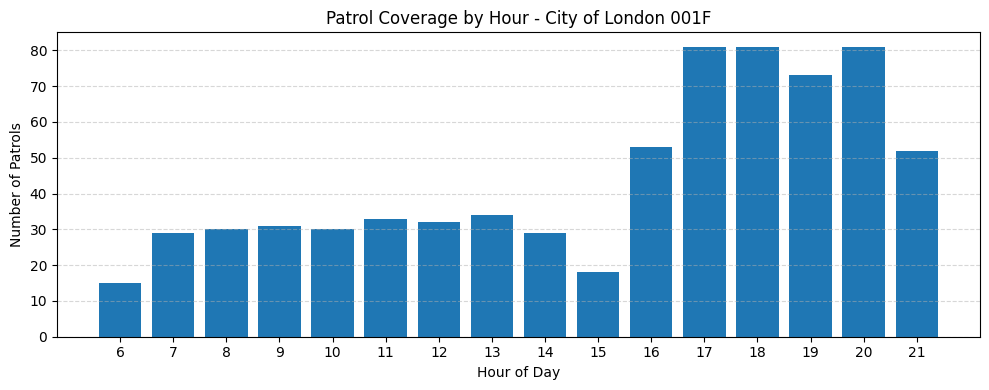

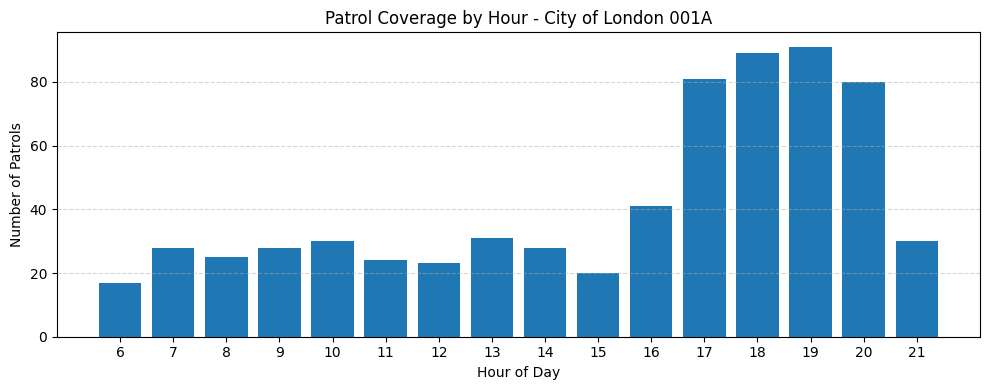

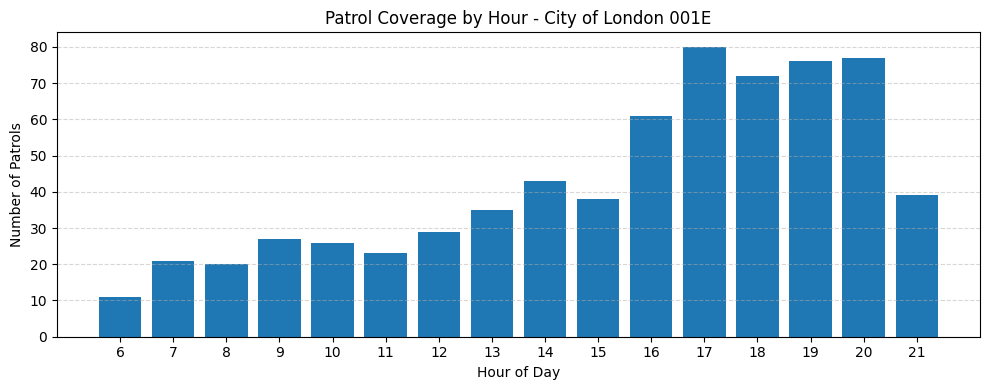

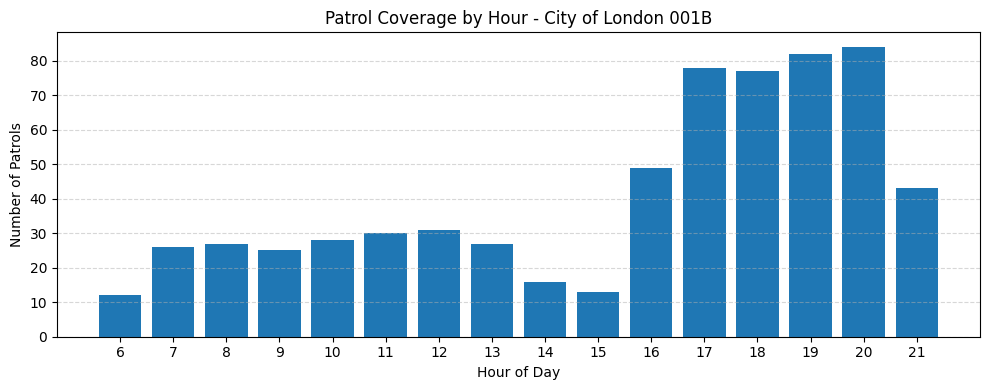

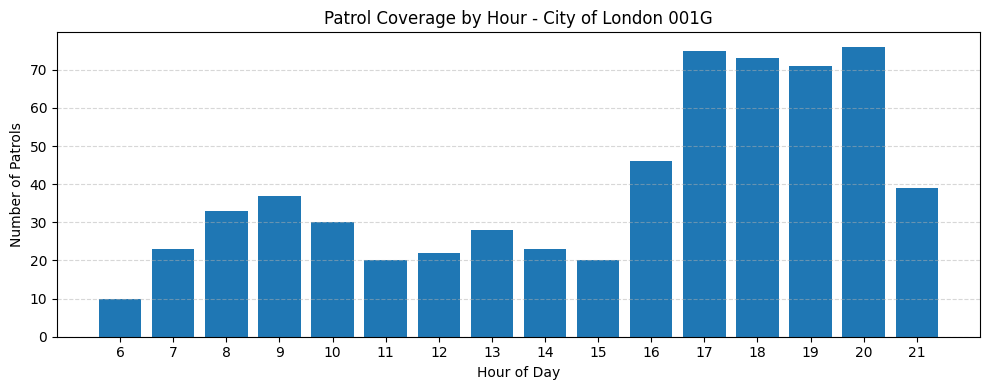

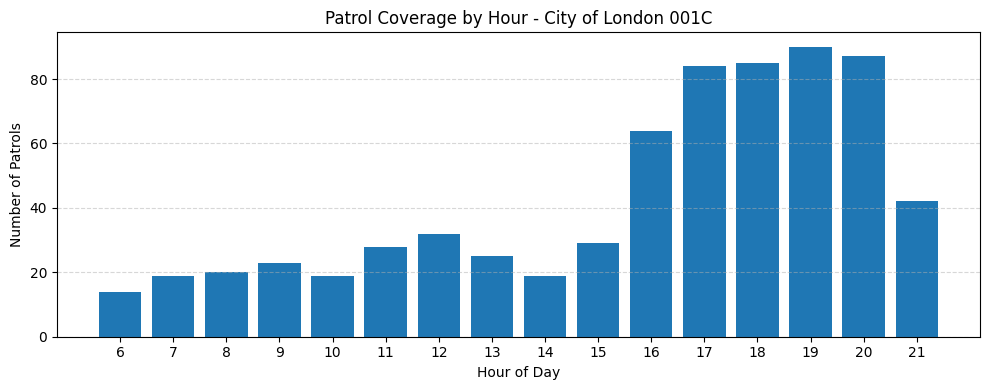

In [38]:
#1st check which hrs are patrolled
lsoa_patrols = {}

for _, row in schedule_df.iterrows():
    for cell in row[1:]:
        if pd.isna(cell):
            continue
        try:
            parts = cell.split('|')
            if len(parts) != 2:
                continue
            time_str = parts[0].strip()
            start_hour = int(time_str.split(':')[0])
            lsoa = parts[1].strip()
            hours = [start_hour, start_hour + 1]

            if lsoa not in lsoa_patrols:
                lsoa_patrols[lsoa] = {h: 0 for h in range(6, 22)}

            for h in hours:
                if h in lsoa_patrols[lsoa]:
                    lsoa_patrols[lsoa][h] += 1
        except Exception as e:
            print(f"Skipping entry '{cell}' due to error: {e}")

# Plot em
for lsoa, hourly_counts in lsoa_patrols.items():
    plt.figure(figsize=(10, 4))
    plt.bar(hourly_counts.keys(), hourly_counts.values())
    plt.title(f"Patrol Coverage by Hour - {lsoa}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Patrols")
    plt.xticks(range(6, 22))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



In [27]:
#more schedule analysis
#check popo hrs
# weeks in the month
week_ranges = {
    "Week 1": [f"Day {i}" for i in range(1, 8)],
    "Week 2": [f"Day {i}" for i in range(8, 15)],
    "Week 3": [f"Day {i}" for i in range(15, 22)],
    "Week 4": [f"Day {i}" for i in range(22, 29)],
}

violations = []
for idx, row in schedule_df.iterrows():
    officer_id = row['Officer ID']
    for week_name, days in week_ranges.items():
        # Count only if the cell is not empty or purely whitespace
        patrol_days = sum(
            pd.notna(row[day]) and str(row[day]).strip() != '' for day in days
        )
        if patrol_days > 4:
            violations.append((officer_id, week_name, patrol_days))
print(violations)

for officer_id, week_name, count in violations:
    print(f"Officer {officer_id} works {count} days in {week_name} (limit is 4)")

# now getting all popo patrol hrs
day_columns = [col for col in schedule_df.columns if col.startswith("Day ")]

# Each entry is a 2-hour shift
total_shifts = sum(
    schedule_df[day].apply(lambda x: pd.notna(x) and str(x).strip() != '').sum()
    for day in day_columns
)

# total hours
total_hours_worked = total_shifts * 2

print(f"Total number of shifts: {total_shifts}")
print(f"Total patrol hours: {total_hours_worked}")

# # of shifts per officer
day_columns = [col for col in schedule_df.columns if col.startswith("Day ")]

# shifts per officer
schedule_df["Shifts Worked"] = schedule_df[day_columns].apply(
    lambda row: row.apply(lambda x: pd.notna(x) and str(x).strip() != '').sum(), axis=1
)

officer_shifts = schedule_df[["Officer ID", "Shifts Worked"]]



[]
Total number of shifts: 2000
Total patrol hours: 4000


In [61]:
officer_shifts.head(100)

,Officer ID,Shifts Worked
0,Abbey_Officer_1,20
1,Abbey_Officer_2,20
2,Abbey_Officer_3,20
3,Abbey_Officer_4,20
4,Abbey_Officer_5,20
...,...,...
95,Abbey_Officer_96,20
96,Abbey_Officer_97,20
97,Abbey_Officer_98,20
98,Abbey_Officer_99,20


There are 4 LSOAs that don't really fit that well into wards:

Hillingdon 015F
- fits into wards Uxbridge North (74%) and Uxbridge South
Hackney 002F
- fits into wards Brownswood (66%)
Southwark 022F
-  fits into wards Peckham (64%)
Southwark 009F
- fits into wards East Walworth (57%)

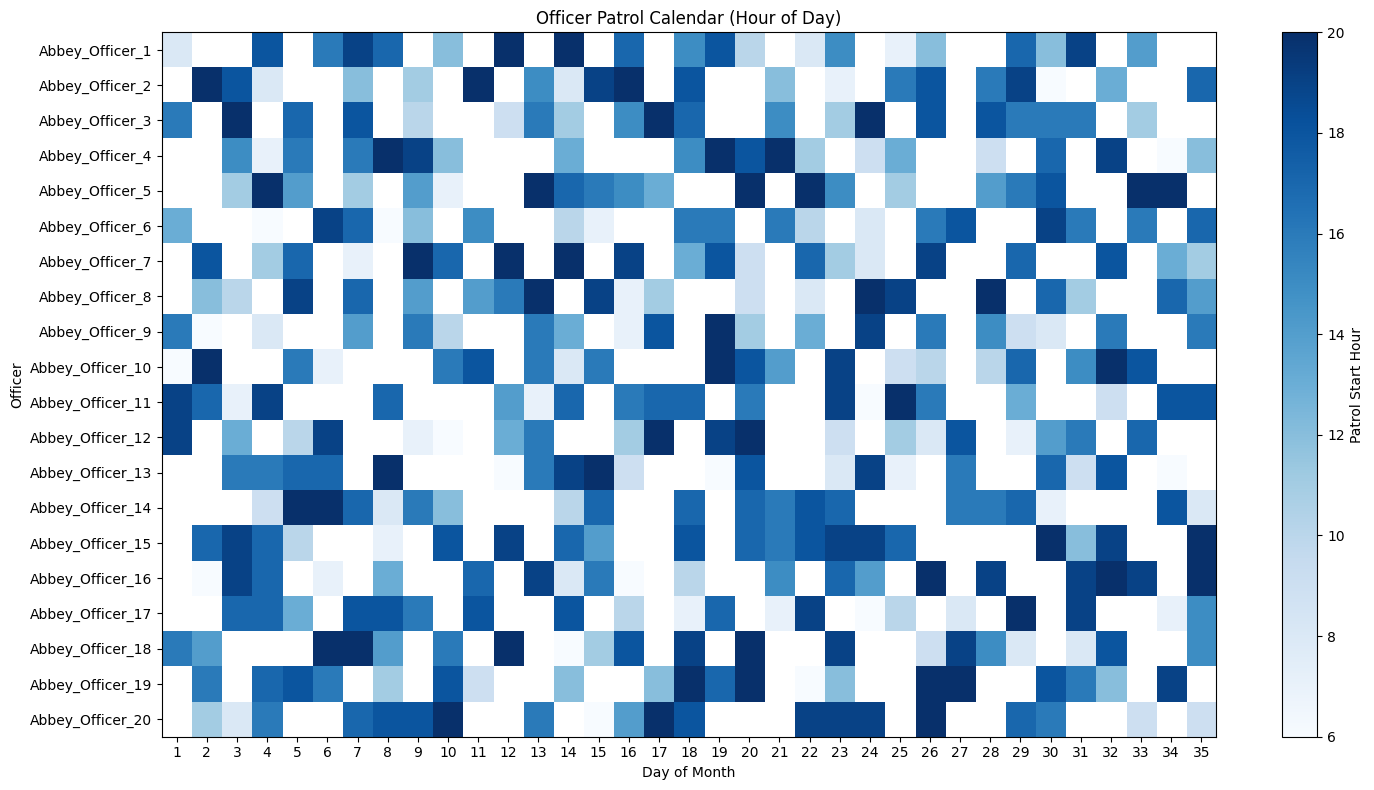

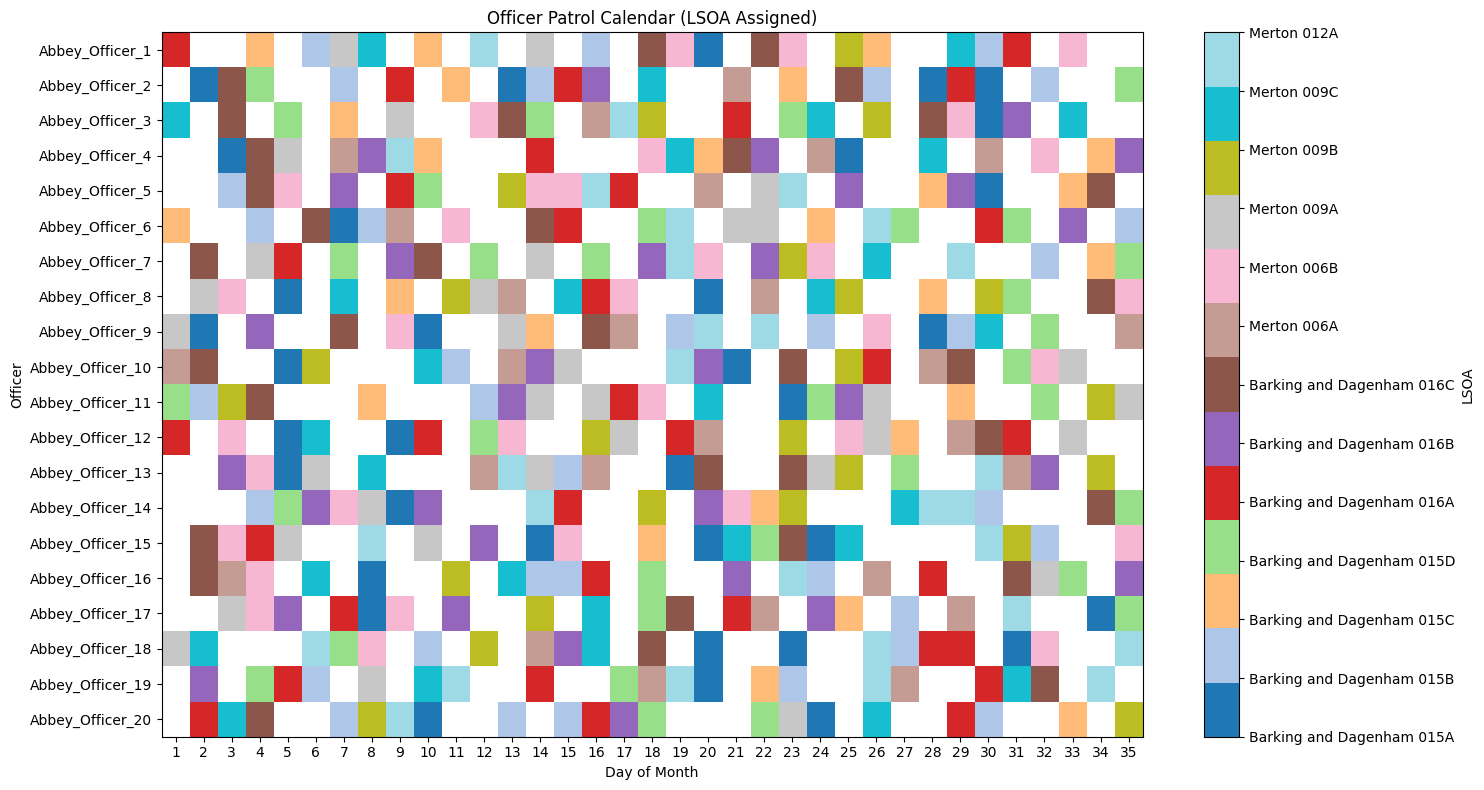

In [28]:
overview = schedule_df.copy()

day_cols = [col for col in overview.columns if col.startswith("Day")]

#color=when the officer goes out (lighter = later)

for col in day_cols:
    overview[col] = overview[col].apply(
        lambda x: int(x.split(":")[0]) if isinstance(x, str) and x.strip() != '' else np.nan
    )

fig, ax = plt.subplots(figsize=(15, 8))

# subset
subset = overview.head(20).set_index("Officer ID")

cax = ax.imshow(subset[day_cols], cmap="Blues", aspect="auto", interpolation="none")

ax.set_title("Officer Patrol Calendar (Hour of Day)")
ax.set_xlabel("Day of Month")
ax.set_ylabel("Officer")


ax.set_xticks(np.arange(len(day_cols)))
ax.set_xticklabels([col.replace("Day ", "") for col in day_cols])

ax.set_yticks(np.arange(len(subset)))
ax.set_yticklabels(subset.index)

# colorbar
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Patrol Start Hour")

plt.tight_layout()
plt.show()

#where the officer goes out



lsoa_names = []
for entry in pd.unique(schedule_df[day_cols].values.ravel()):
    if isinstance(entry, str) and '|' in entry:
        try:
            lsoa = entry.split('|')[1].strip()
            lsoa_names.append(lsoa)
        except IndexError:
            continue

if len(lsoa_names) == 0:
    raise ValueError("No valid LSOA entries found in the schedule.")

unique_lsoas = sorted(set(lsoa_names))
lsoa_to_int = {name: i for i, name in enumerate(unique_lsoas)}
int_to_lsoa = {v: k for k, v in lsoa_to_int.items()}

overview = schedule_df.copy()
for col in day_cols:
    def extract_lsoa_as_int(cell):
        if isinstance(cell, str) and '|' in cell:
            try:
                lsoa = cell.split('|')[1].strip()
                return lsoa_to_int.get(lsoa, np.nan)
            except:
                return np.nan
        return np.nan
    overview[col] = overview[col].apply(extract_lsoa_as_int)

subset = overview.head(20).set_index("Officer ID")
fig, ax = plt.subplots(figsize=(15, 8))

num_lsoas = len(unique_lsoas)
colors = plt.get_cmap('tab20', num_lsoas)
cmap = ListedColormap(colors.colors)

cax = ax.imshow(subset[day_cols], cmap=cmap, aspect="auto", interpolation="none")
ax.set_title("Officer Patrol Calendar (LSOA Assigned)")
ax.set_xlabel("Day of Month")
ax.set_ylabel("Officer")
ax.set_xticks(np.arange(len(day_cols)))
ax.set_xticklabels([col.replace("Day ", "") for col in day_cols])
ax.set_yticks(np.arange(len(subset)))
ax.set_yticklabels(subset.index)

cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(num_lsoas))
cbar.ax.set_yticklabels([int_to_lsoa[i] for i in range(num_lsoas)])
cbar.set_label("LSOA")

plt.tight_layout()
plt.show()








In [44]:
# Get official LSOAs in the ward (e.g., "Abbey")
ward_name = "Abbey"
official_lsoas = set(
    lsoa_pct_ward.loc[lsoa_pct_ward['Ward'] == ward_name, 'LSOA name'].dropna().unique()
)

# Extract scheduled LSOAs from the schedule
day_cols = [col for col in schedule_df.columns if col.startswith("Day")]
scheduled_lsoas = set()

for col in day_cols:
    scheduled_lsoas.update(
        schedule_df[col].dropna().apply(
            lambda x: x.split('|')[1].strip() if '|' in x else None
        ).dropna()
    )

# Compare
print(f"Total LSOAs in '{ward_name}' ward: {len(official_lsoas)}")
print(f"Total unique LSOAs scheduled: {len(scheduled_lsoas)}")
print(f"LSOAs not scheduled: {len(official_lsoas - scheduled_lsoas)}")

# Optionally print which were missed
print("\nLSOAs in ward but not scheduled:")
for lsoa in sorted(official_lsoas - scheduled_lsoas):
    print("-", lsoa)


Total LSOAs in 'Abbey' ward: 13
Total unique LSOAs scheduled: 13
LSOAs not scheduled: 0

LSOAs in ward but not scheduled:
